In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master_df = pd.read_csv('Team_Stats_Merge_2018_2025.csv')

In [3]:
master_df.info

<bound method DataFrame.info of      season                  team  tp_W  tp_L  tp_T  tp_W-L%  tp_PF  tp_PA  \
0      2018  New England Patriots    11     5   0.0    0.688    436    325   
1      2018        Miami Dolphins     7     9   0.0    0.438    319    433   
2      2018         Buffalo Bills     6    10   0.0    0.375    269    374   
3      2018         New York Jets     4    12   0.0    0.250    333    441   
4      2018      Baltimore Ravens    10     6   0.0    0.625    389    287   
..      ...                   ...   ...   ...   ...      ...    ...    ...   
251    2025    New Orleans Saints     6    11   0.0    0.353    306    383   
252    2025      Seattle Seahawks    14     3   0.0    0.824    483    292   
253    2025      Los Angeles Rams    12     5   0.0    0.706    518    346   
254    2025   San Francisco 49ers    12     5   0.0    0.706    437    371   
255    2025     Arizona Cardinals     3    14   0.0    0.176    355    488   

     tp_PD  tp_MoV  ...  def_ad

In [4]:
corr_matrix = master_df.corr(numeric_only=True)

In [5]:


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.85)
]

print(high_corr)

['tp_L', 'tp_W-L%', 'tp_PD', 'tp_MoV', 'tp_SRS', 'tp_OSRS', 'tp_DSRS', 'off_pts', 'off_yds', 'off_yds_per_play', 'off_penalty_yds', 'off_score_pct', 'off_turnover_pct', 'off_exp', 'def_g', 'def_pa', 'def_yds_per_play', 'def_score_pct', 'def_turnover_pct', 'def_exp', 'off_pass_G', 'off_pass_Att', 'off_pass_TD%', 'off_pass_Int', 'off_pass_Int%', 'off_pass_Y/A', 'off_pass_AY/A', 'off_pass_Y/G', 'off_pass_Rate', 'off_pass_Yds.1', 'off_pass_Sk%', 'off_pass_NY/A', 'off_pass_ANY/A', 'off_pass_EXP', 'off_rush_G', 'off_rush_Yds', 'off_rush_Y/G', 'def_pass_G', 'def_pass_Att', 'def_pass_TD%', 'def_pass_Int', 'def_pass_Int%', 'def_pass_Y/A', 'def_pass_AY/A', 'def_pass_Y/G', 'def_pass_Rate', 'def_pass_Yds.1', 'def_pass_Sk%', 'def_pass_NY/A', 'def_pass_ANY/A', 'def_pass_EXP', 'def_rush_G', 'def_rush_Y/G', 'def_adv_G', 'def_adv_Att', 'def_adv_Cmp', 'def_adv_Yds', 'def_adv_TD', 'def_adv_Sk']


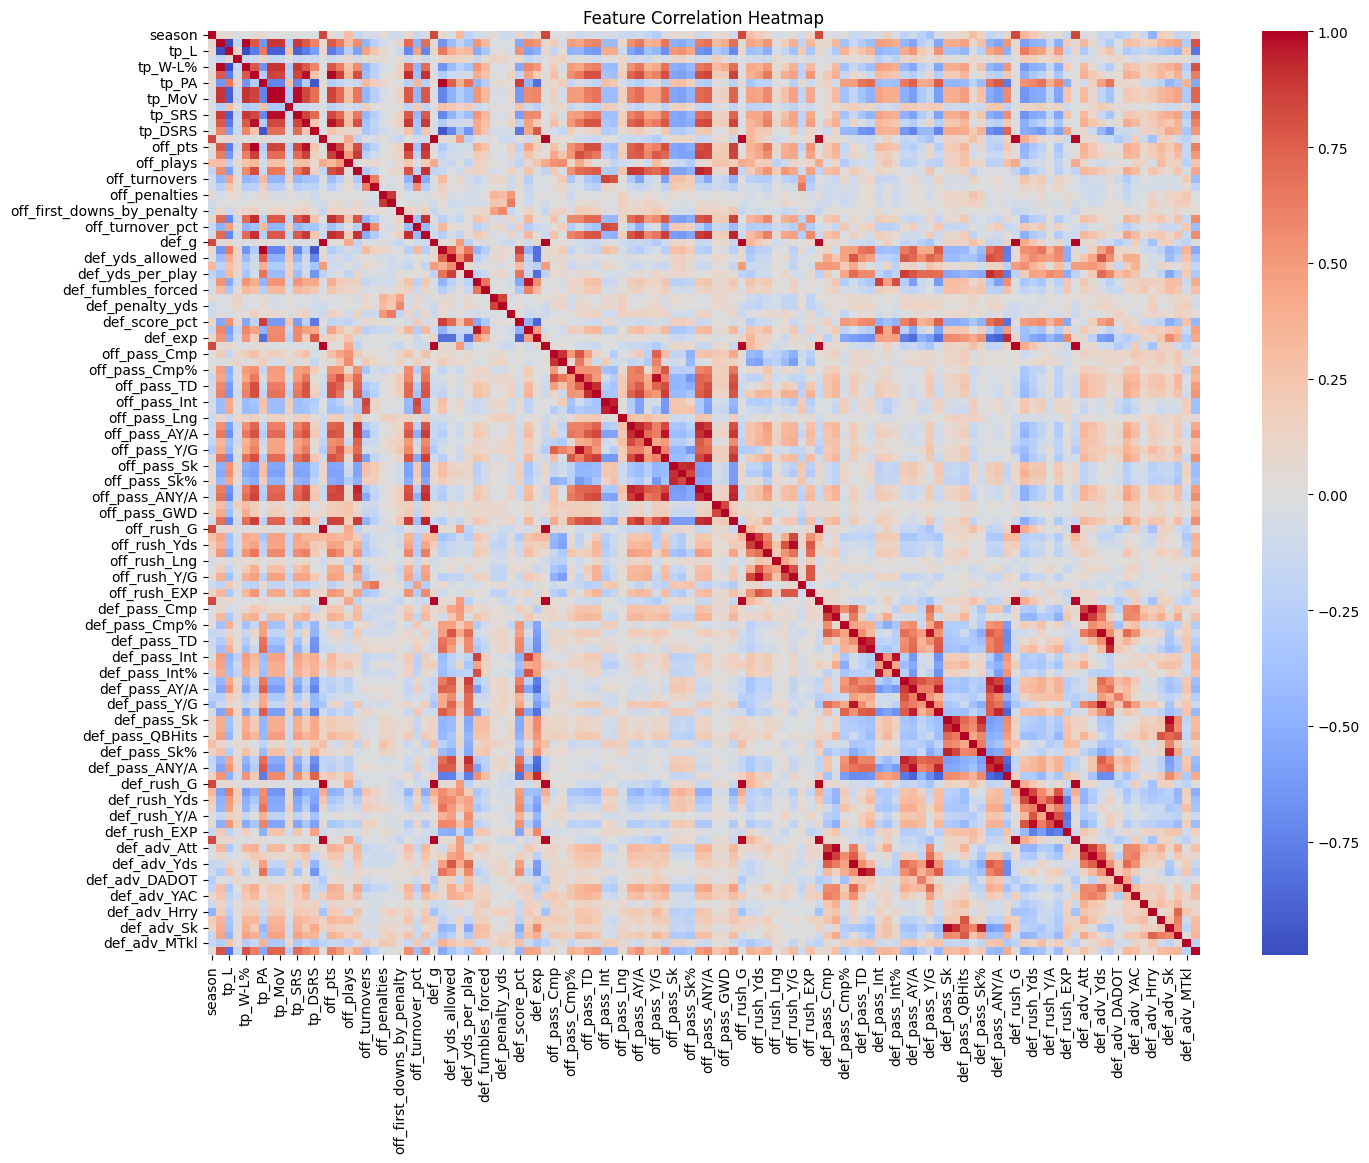

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(master_df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

## Test All Feautres

In [7]:
# Drop non-feature columns
drop_cols = ["season", "team", "made_playoffs"]  # adjust if needed

X = master_df.drop(columns=drop_cols)
y = master_df["made_playoffs"]

In [8]:
X.info

<bound method DataFrame.info of      tp_W  tp_L  tp_T  tp_W-L%  tp_PF  tp_PA  tp_PD  tp_MoV  tp_SoS  tp_SRS  \
0      11     5   0.0    0.688    436    325    111     6.9    -1.8     5.2   
1       7     9   0.0    0.438    319    433   -114    -7.1    -1.7    -8.8   
2       6    10   0.0    0.375    269    374   -105    -6.6    -0.3    -6.9   
3       4    12   0.0    0.250    333    441   -108    -6.8    -1.1    -7.8   
4      10     6   0.0    0.625    389    287    102     6.4     0.6     7.0   
..    ...   ...   ...      ...    ...    ...    ...     ...     ...     ...   
251     6    11   0.0    0.353    306    383    -77    -4.5    -0.3    -4.9   
252    14     3   0.0    0.824    483    292    191    11.2     1.6    12.8   
253    12     5   0.0    0.706    518    346    172    10.1     2.4    12.5   
254    12     5   0.0    0.706    437    371     66     3.9     2.1     6.0   
255     3    14   0.0    0.176    355    488   -133    -7.8     3.4    -4.4   

     ...  def_adv_B

## Handle difference in inconsistent rates vs totals

We will add a 
* feature for fumble rate to be consistent with Int rate : off_Fmb% = off_fumbles/ off_plays * 100
* feature for fumble rate to be consistent with Int rate : off_rush_TD% = off_rush_TD / off_rush_Att * 100


In [9]:
X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
X['off_rush_TD%'] = X['off_rush_TD']/X['off_rush_Att']
X['def_rush_TD%'] = X['def_rush_TD']/X['def_rush_Att']

/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3137632844.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3137632844.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['off_rush_TD%'] = X['off_rush_TD']/X['off_rush_Att']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3137632844.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [10]:
X.columns.tolist()

['tp_W',
 'tp_L',
 'tp_T',
 'tp_W-L%',
 'tp_PF',
 'tp_PA',
 'tp_PD',
 'tp_MoV',
 'tp_SoS',
 'tp_SRS',
 'tp_OSRS',
 'tp_DSRS',
 'off_g',
 'off_pts',
 'off_yds',
 'off_plays',
 'off_yds_per_play',
 'off_turnovers',
 'off_fumbles',
 'off_penalties',
 'off_penalty_yds',
 'off_first_downs_by_penalty',
 'off_score_pct',
 'off_turnover_pct',
 'off_exp',
 'def_g',
 'def_pa',
 'def_yds_allowed',
 'def_plays',
 'def_yds_per_play',
 'def_turnovers_forced',
 'def_fumbles_forced',
 'def_penalties',
 'def_penalty_yds',
 'def_first_downs_by_penalty',
 'def_score_pct',
 'def_turnover_pct',
 'def_exp',
 'off_pass_G',
 'off_pass_Cmp',
 'off_pass_Att',
 'off_pass_Cmp%',
 'off_pass_Yds',
 'off_pass_TD',
 'off_pass_TD%',
 'off_pass_Int',
 'off_pass_Int%',
 'off_pass_Lng',
 'off_pass_Y/A',
 'off_pass_AY/A',
 'off_pass_Y/C',
 'off_pass_Y/G',
 'off_pass_Rate',
 'off_pass_Sk',
 'off_pass_Yds.1',
 'off_pass_Sk%',
 'off_pass_NY/A',
 'off_pass_ANY/A',
 'off_pass_4QC',
 'off_pass_GWD',
 'off_pass_EXP',
 'off_rush_

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

ValueError: could not convert string to float: '32.90%'

In [237]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(25)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

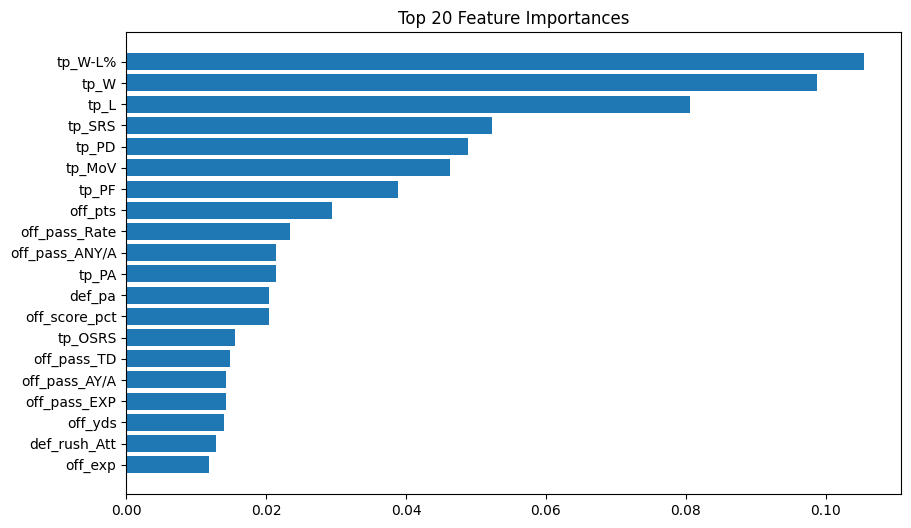

In [238]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

## Eliminate trival/nonrelevant features

Features that are obvious and should be remove because of noise.

Example:
Wins and scoring Points = playoffs 
Losses and giving up points != playoffs
Easier Schedule = playoffs

In [ ]:
trivial_features = ['tp_W-L%',
                    'tp_W',
                    'tp_L',
                    'tp_PD',
                    'tp_MoV',
                    'tp_PF',
                    'tp_PA',
                    'tp_T',
                    'off_pts',
                    'def_pa',
                    'tp_SoS',
                    ]

## Eliminate aggregated / calculated features

These are features that will highly correlated and do not give signifcant interpretablebilty

Examples
* Anything with EXP/SRS (expect points and rating system) - not insightful - better teams get better ratings
* Total off/def yards - more interested in seeing passing and rushing splits not the total - 
* Total Efficiencies - more interested in seeing passing and rushing splits not the total - rush/pass Y/A instead of yds per play
* Efficieny > Volume - more interested in Yards/Attempt than Yards/Game
* Passing - Yards/Attempt > Yards/Completion - represents a better efficiency of yards gained per pass attempted rather than just the completed ones
* Rushing and Passing Attempt numbers as a whole falls under totals for me. After efficiency


In [ ]:
aggregated_features = ['def_exp',
                       'off_exp',
                       'off_rush_exp',
                       'off_yds',
                       'def_yds_allowed',
                       'def_pass_AY/A',
                       'off_pass_AY/A',
                       'off_pass_ANY/A',
                       'def_pass_ANY/A',
                       'off_rush_EXP',
                       'def_rush_EXP',
                        'off_pass_EXP',
                        'def_pass_EXP',
                        'off_yds_per_play',
                        'def_yds_per_play',
                        'off_rush_G',
                        'def_rush_G',
                        'def_adv_G',
                        'off_pass_G',
                        'def_pass_G',
                        'off_g',
                        'def_g',
                        'off_pass_Yds',
                        'def_rush_Yds',
                        'off_rush_Yds',
                        'def_pass_Yds',
                        'off_pass_Y/G',
                        'def_rush_Y/G',
                        'off_pass_TD',
                        'def_rush_Att',
                        'off_rush_Att',
                        'off_rush_Y/G',
                        'off_pass_Yds.1',
                        'def_pass_Yds.1',
                        'def_plays',
                        'off_plays',
                       ]

## Eliminate Situation Features

These are features that are too niche to the situation of the game. 

Examples
* Penalties - too random and obviously negative
* Game Winning Drives (GWD) - power house teams may not ever be in situation of GWD
* 4th Quarter Comback (4QC) - same as GWD


In [ ]:
situational_features = ['off_penalties',
                        'def_penalties',
                        'def_penalty_yds',
                        'off_penalty_yds',]

In [175]:
trivial_features = ['tp_W-L%',
                    'tp_L',
                    'tp_W',
                    'tp_PD',
                    'tp_SRS',
                    'tp_OSRS',
                    'tp_DSRS',
                    'off_pts',
                    'def_pa',
                    'tp_MoV',
                    'def_pass_AY/A',
                    'off_pass_AY/A',
                    'off_pass_NY/A',
                    'def_pass_NY/A',
                    'def_pass_Y/A',
                    'off_pass_Y/A',
                    'tp_PF',
                    'tp_PA',
                    'def_exp',
                    'off_exp',
                    'off_rush_exp',
                    'off_yds',
                    'def_yds_allowed',
                    'off_turnovers',
                    'def_turnovers_forced',
                    'off_pass_Yds',
                    'def_rush_Yds',
                    'off_rush_Yds',
                    'def_pass_Yds',
                    'off_pass_TD',
                    'off_pass_Y/G',
                    'def_rush_Y/G',
                    'off_pass_Cmp%',
                    'def_rush_Att',
                    'off_rush_Att',
                    'off_rush_Y/G',
                    'def_pass_PD',
                    'off_pass_Int',
                    'def_pass_Int',
                    'off_pass_Yds.1',
                    'def_pass_Yds.1',
                    'off_pass_Sk',
                    'off_pass_Sk%',
                    'def_pass_Sk%',
                    'def_pass_Sk',
                    'off_pass_GWD',
                    'def_plays',
                    'off_plays',
                    'def_pass_Att',
                    'def_rush_TD',
                    'off_rush_TD',
                    'off_pass_Y/C',
                    'def_pass_Cmp%',
                    'off_rush_Lng',
                    'off_pass_Att',
                    'def_adv_Att',
                    'def_pass_TD',
                    'def_pass_Y/C',
                    'off_pass_Y/G',
                    'off_rush_fumbles',
                    'def_pass_Y/G',
                    'off_pass_Cmp',
                    'tp_SoS',
                    'def_pass_TFL',
                    'off_pass_Lng',
                    'def_adv_Yds',
                    'def_pass_TD%',
                    'def_adv_Sk',
                    'def_adv_Cmp',
                    'def_penalties',
                    'def_penalty_yds',
                    'off_penalty_yds',
                    'def_pass_Cmp',
                    'off_penalties',
                    'def_adv_TD',
                    'off_pass_4QC',
                    'def_first_downs_by_penalty',
                    'off_first_downs_by_penalty',
                    'tp_T',
                    'off_pass_G',
                    'def_pass_G',
                    'off_g',
                    'def_g',
                    'off_rush_Fmb',
                    'off_rush_G',
                    'def_rush_G',
                    'def_adv_G',
                    'off_rush_EXP',
                    'def_rush_EXP',
                    'off_pass_EXP',
                    'def_pass_EXP',
                    'off_yds_per_play',
                    'def_yds_per_play',
                    'def_pass_Int%', 'def_adv_Bltz%', 'def_adv_Hrry%', 'def_adv_QBKD%', 'def_adv_Prss%'
                    ]

In [176]:
X = X.drop(columns=trivial_features, errors='ignore')

In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [178]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance


,feature,importance
1,off_score_pct,0.118900
8,off_pass_Rate,0.101270
9,off_pass_ANY/A,0.093394
4,def_score_pct,0.073993
13,def_pass_ANY/A,0.072020
6,off_pass_TD%,0.064670
5,def_turnover_pct,0.059276
11,def_pass_Rate,0.058345
2,off_turnover_pct,0.052249
12,def_pass_QBHits,0.039254


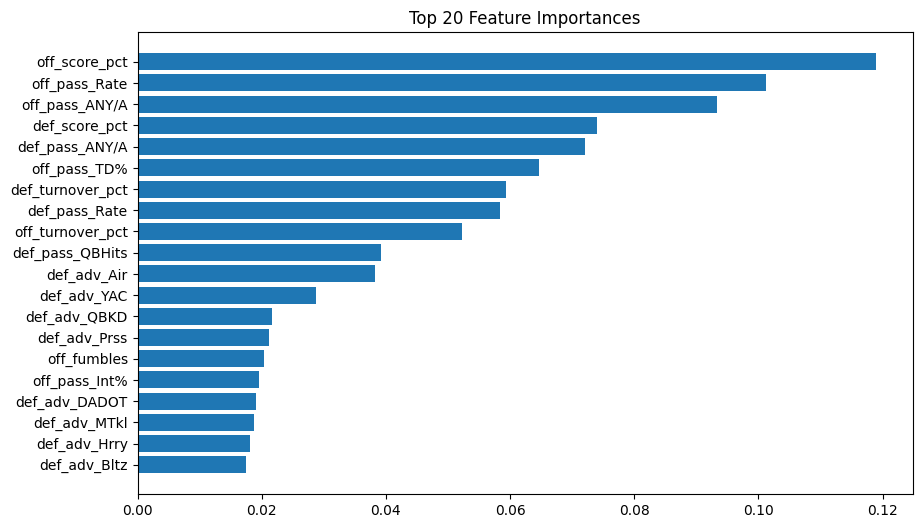

In [179]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [180]:
X


,off_fumbles,off_score_pct,off_turnover_pct,def_fumbles_forced,def_score_pct,def_turnover_pct,off_pass_TD%,off_pass_Int%,off_pass_Rate,off_pass_ANY/A,...,def_pass_ANY/A,def_rush_Y/A,def_adv_DADOT,def_adv_Air,def_adv_YAC,def_adv_Bltz,def_adv_Hrry,def_adv_QBKD,def_adv_Prss,def_adv_MTkl
0,7,40.8,9.2,10,32.6,15.0,5.1,1.9,97.8,7.3,...,5.8,4.9,9.9,2880,2075,205,71,53,154,73
1,10,28.3,12.5,7,39.9,14.2,5.7,2.9,93.0,5.6,...,6.7,4.8,8.5,2006,1905,146,79,36,146,119
2,9,26.4,15.5,11,33.3,14.3,2.6,4.6,62.6,3.7,...,4.9,4.2,7.2,1553,1482,128,76,41,153,137
3,11,32.0,14.7,7,39.1,9.9,3.4,3.6,73.0,4.8,...,6.5,4.6,8.6,2356,1879,202,62,54,155,115
4,11,40.7,10.7,5,29.1,9.5,3.2,1.6,84.0,6.0,...,5.2,3.7,8.3,2020,1684,252,94,47,184,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,12,33.0,13.1,10,40.2,11.2,3.2,2.0,88.7,5.6,...,5.8,4.0,8.1,1710,1605,128,62,34,141,94
252,13,45.9,14.2,7,28.7,12.8,5.2,3.1,97.9,7.3,...,4.5,3.7,6.9,1698,2060,133,73,60,180,110
253,7,47.0,8.3,10,34.3,14.9,7.7,1.3,109.0,8.2,...,5.5,4.3,8.0,2533,1947,117,61,66,174,82
254,6,47.6,12.9,10,38.6,8.4,5.7,2.8,98.8,6.8,...,7.1,4.3,7.8,2403,1939,116,48,38,106,88


In [181]:
print("Shape:", X.shape)
print("Any NaN?", X.isna().sum().sum())
print("Any inf?", np.isinf(X).sum().sum())

Shape: (256, 23)
Any NaN? 0
Any inf? 0


In [182]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
print(vif)

               Feature          VIF
21        def_adv_Prss  2038.975949
11       def_pass_Rate  1626.523490
13      def_pass_ANY/A  1092.973162
8        off_pass_Rate  1012.497904
12     def_pass_QBHits   490.298262
9       off_pass_ANY/A   426.109994
19        def_adv_Hrry   330.259422
15       def_adv_DADOT   247.312558
2     off_turnover_pct   185.626992
4        def_score_pct   183.572032
14        def_rush_Y/A   173.283297
1        off_score_pct   150.636565
10        off_rush_Y/A   140.596552
16         def_adv_Air   136.280531
17         def_adv_YAC   114.738475
20        def_adv_QBKD   114.138498
7        off_pass_Int%    80.762559
6         off_pass_TD%    70.052280
5     def_turnover_pct    50.437968
0          off_fumbles    39.511056
22        def_adv_MTkl    33.524732
3   def_fumbles_forced    21.209892
18        def_adv_Bltz    16.313380


### After Running the VIF eliminate extreme values

season
team
tp_W
tp_L
tp_T
tp_W-L%
tp_PF
tp_PA
tp_PD
tp_MoV
tp_SoS
tp_SRS
tp_OSRS
tp_DSRS
off_g
off_pts
off_yds
off_plays
off_yds_per_play
off_turnovers
off_fumbles
off_penalties
off_penalty_yds
off_first_downs_by_penalty
off_score_pct
off_turnover_pct
off_exp
def_g
def_pa
def_yds_allowed
def_plays
def_yds_per_play
def_turnovers_forced
def_fumbles_forced
def_penalties
def_penalty_yds
def_first_downs_by_penalty
def_score_pct
def_turnover_pct
def_exp
off_pass_G
off_pass_Cmp
off_pass_Att
off_pass_Cmp%
off_pass_Yds
off_pass_TD
off_pass_TD%
off_pass_Int
off_pass_Int%
off_pass_Lng
off_pass_Y/A
off_pass_AY/A
off_pass_Y/C
off_pass_Y/G
off_pass_Rate
off_pass_Sk
off_pass_Yds.1
off_pass_Sk%
off_pass_NY/A
off_pass_ANY/A
off_pass_4QC
off_pass_GWD
off_pass_EXP
off_rush_G
off_rush_Att
off_rush_Yds
off_rush_TD
off_rush_Lng
off_rush_Y/A
off_rush_Y/G
off_rush_Fmb
off_rush_EXP
def_pass_G
def_pass_Cmp
def_pass_Att
def_pass_Cmp%
def_pass_Yds
def_pass_TD
def_pass_TD%
def_pass_Int
def_pass_PD
def_pass_Int%
d

In [50]:

features = [
'tp_SRS','tp_PD',
'off_yds_per_play','off_score_pct','off_turnover_pct','off_exp',
'off_pass_ANY/A','off_pass_TD%','off_pass_Int%',
'off_rush_Y/G','off_rush_EXP',
'def_yds_per_play','def_score_pct','def_turnover_pct','def_exp',
'def_pass_ANY/A','def_pass_Sk%','def_rush_Y/G',
'off_penalty_yds','def_penalty_yds'
]

X = master_df[features]
y = master_df["made_playoffs"]

In [51]:
model_df = pd.concat(
    [
        master_df[["season","team"]],  # identifiers
        X,
        y
    ],
    axis=1
)

model_df

,season,team,tp_SRS,tp_PD,off_yds_per_play,off_score_pct,off_turnover_pct,off_exp,off_pass_ANY/A,off_pass_TD%,...,def_yds_per_play,def_score_pct,def_turnover_pct,def_exp,def_pass_ANY/A,def_pass_Sk%,def_rush_Y/G,off_penalty_yds,def_penalty_yds,made_playoffs
0,2018,New England Patriots,5.2,111,5.9,40.8,9.2,147.66,7.3,5.1,...,5.7,32.6,15.0,-17.25,5.8,4.7,112.7,744,838,1
1,2018,Miami Dolphins,-8.8,-114,5.3,28.3,12.5,-44.43,5.6,5.7,...,6.1,39.9,14.2,-127.44,6.7,5.8,145.3,978,856,0
2,2018,Buffalo Bills,-6.9,-105,4.7,26.4,15.5,-96.90,3.7,2.6,...,4.9,33.3,14.3,16.95,4.9,6.8,114.9,992,976,0
3,2018,New York Jets,-7.8,-108,4.9,32.0,14.7,-97.61,4.8,3.4,...,5.7,39.1,9.9,-70.75,6.5,6.3,126.3,948,817,0
4,2018,Baltimore Ravens,7.0,102,5.3,40.7,10.7,81.02,6.0,3.2,...,4.8,29.1,9.5,30.09,5.2,6.9,82.9,940,1017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,-4.9,-77,5.0,33.0,13.1,-19.68,5.6,3.2,...,4.8,40.2,11.2,4.59,5.8,8.4,120.6,920,913,0
252,2025,Seattle Seahawks,12.8,191,5.9,45.9,14.2,80.50,7.3,5.2,...,4.6,28.7,12.8,81.09,4.5,7.3,91.9,793,902,1
253,2025,Los Angeles Rams,12.5,172,6.2,47.0,8.3,219.88,8.2,7.7,...,5.2,34.3,14.9,6.16,5.5,7.4,110.8,573,922,1
254,2025,San Francisco 49ers,6.0,66,5.5,47.6,12.9,131.06,6.8,5.7,...,5.6,38.6,8.4,-115.46,7.1,3.3,107.8,651,734,1


In [52]:
model_df.to_csv("team_stats_model_ready.csv", index=False)